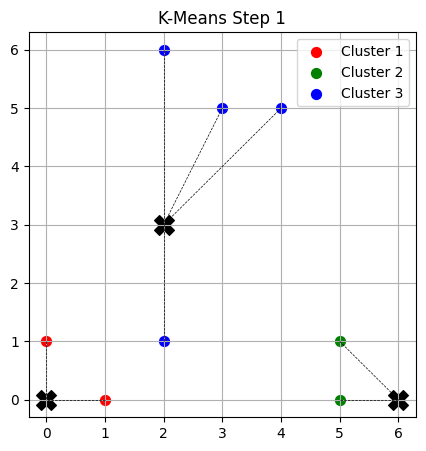

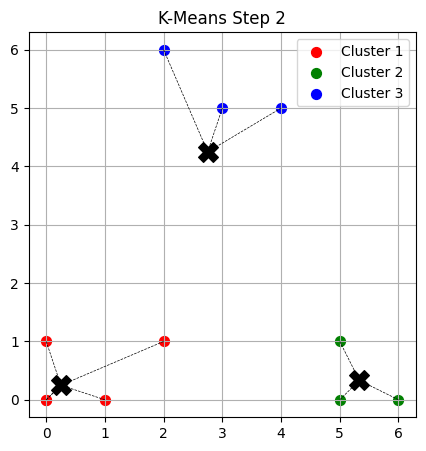

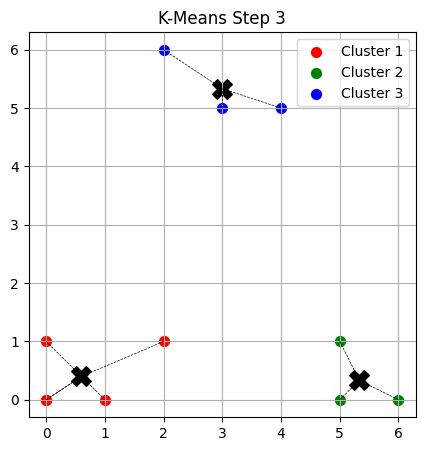

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Data points
points = np.array([
    [0, 0], [0, 1], [1, 0],
    [5, 0], [5, 1], [6, 0],
    [3, 5], [2, 6], [4, 5],
    [2, 1], [0, 0]
])

# Function to plot a step
def plot_kmeans_step(X, centroids, labels, step, show_dist=False):
    plt.figure(figsize=(5, 5))
    colors = ['r', 'g', 'b']
    for i in range(len(centroids)):
        plt.scatter(X[labels == i, 0], X[labels == i, 1],
                    c=colors[i], s=50, label=f'Cluster {i+1}')
        plt.scatter(centroids[i][0], centroids[i][1],
                    c='k', marker='X', s=200)
        if show_dist:
            for point in X[labels == i]:
                plt.plot([point[0], centroids[i][0]],
                         [point[1], centroids[i][1]], 'k--', linewidth=0.5)
    plt.title(f'K-Means Step {step}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Assign clusters based on nearest centroid
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

# Update centroid positions
def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

# Step-by-step K-Means
initial_centroids = np.array([[0, 0], [6, 0], [2, 3]])
centroids = initial_centroids

for step in range(1, 6):
    labels = assign_clusters(points, centroids)
    plot_kmeans_step(points, centroids, labels, step, show_dist=True)
    new_centroids = update_centroids(points, labels, 3)
    if np.allclose(new_centroids, centroids):
        break
    centroids = new_centroids
